In [30]:
import numpy as np
import matplotlib.pyplot as plt
import scipy
import astropy.visualization.hist
from sklearn.neighbors import KernelDensity
#from tqdm.notebook import tqdm

import numpy as np
import pylab as plt
import scipy.stats
from tqdm.notebook import tqdm

In [31]:
mu=1
sigma=0.02
N=10000

In [32]:
chi=np.random.uniform(0,1,N)
M=scipy.stats.norm(loc=mu, scale=sigma).rvs(N)

[0.07972098 0.05630657 0.80889722 ... 0.53515665 0.71924501 0.07040937] [1.03923149 1.0025818  1.01259638 ... 1.03665309 0.98006469 0.98854379]


(array([0.97554394, 1.03665183, 0.97554394, 1.00391546, 0.94717241,
        0.99082091, 0.99518576, 1.02137486, 1.06065851, 1.03883426,
        1.02137486, 1.01264516, 1.03228698, 0.96026696, 0.98427364,
        1.01046273, 1.01264516, 1.00828031, 0.99518576, 0.97554394,
        0.97772636, 0.78785539]),
 array([1.17679311e-04, 4.59382706e-02, 9.17588620e-02, 1.37579453e-01,
        1.83400045e-01, 2.29220636e-01, 2.75041227e-01, 3.20861819e-01,
        3.66682410e-01, 4.12503001e-01, 4.58323593e-01, 5.04144184e-01,
        5.49964775e-01, 5.95785367e-01, 6.41605958e-01, 6.87426549e-01,
        7.33247141e-01, 7.79067732e-01, 8.24888323e-01, 8.70708915e-01,
        9.16529506e-01, 9.62350097e-01, 1.00817069e+00]),
 [<matplotlib.patches.Polygon at 0x1fefe1b7250>])

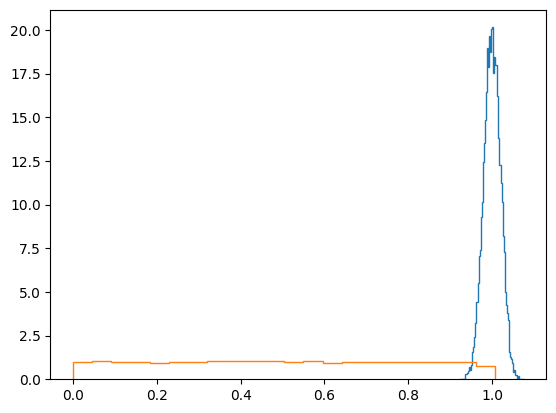

In [33]:
print(chi, M)
astropy.visualization.hist(M, bins="freedman", histtype="step",density=True)
astropy.visualization.hist(chi, bins="freedman", histtype="step",density=True)

In [34]:
def M_irr(M,chi):
    return M*np.sqrt(1+np.sqrt(1-chi**2)/2)

def f(chi):
    return np.sqrt(1+np.sqrt(1-chi**2)/2)

In [35]:
Mirr=M_irr(M,chi)

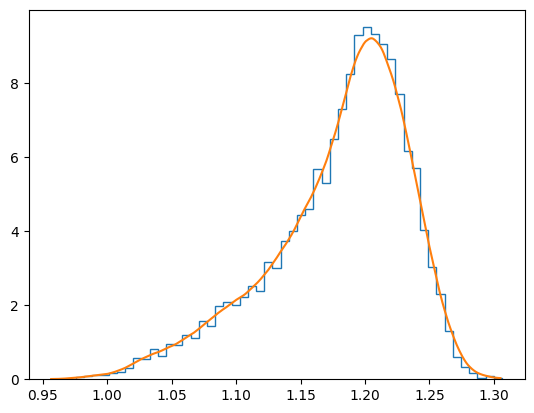

In [36]:
astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)

xgrid = np.linspace(Mirr.min(),Mirr.max(),1000)

def kde_sklearn(data, bandwidth = 1.0, kernel="linear"):
    kde_skl = KernelDensity(bandwidth = bandwidth, 
                            kernel=kernel)
    kde_skl.fit(data[:, np.newaxis])
    log_pdf = kde_skl.score_samples(xgrid[:, np.newaxis]) # sklearn returns log(density)
    return np.exp(log_pdf)

PDFepanechnikov = kde_sklearn(Mirr,bandwidth=0.02,kernel="epanechnikov") 
plt.plot(xgrid,PDFepanechnikov) 

(array([ 0.13521858,  0.23663252,  0.37185111,  0.45636272,  0.62538595,
         0.60848363,  0.81131151,  0.74370221,  0.82821383,  0.99723706,
         1.04794403,  1.26767423,  1.18316261,  1.63952533,  2.07898573,
         1.84235321,  2.23110664,  1.92686483,  2.55225078,  2.67056704,
         2.68746936,  3.14383208,  3.39736693,  3.63399945,  3.60019481,
         4.44531096,  4.61433419,  4.68194348,  5.29042711,  5.76369215,
         6.40598043,  7.43702214,  8.46806384, 10.03997988, 11.71330986,
        15.31350467, 24.39005214, 19.7419133 ]),
 array([1.00444637, 1.01036272, 1.01627906, 1.02219541, 1.02811176,
        1.0340281 , 1.03994445, 1.0458608 , 1.05177714, 1.05769349,
        1.06360984, 1.06952618, 1.07544253, 1.08135888, 1.08727522,
        1.09319157, 1.09910791, 1.10502426, 1.11094061, 1.11685695,
        1.1227733 , 1.12868965, 1.13460599, 1.14052234, 1.14643869,
        1.15235503, 1.15827138, 1.16418773, 1.17010407, 1.17602042,
        1.18193677, 1.18785311, 

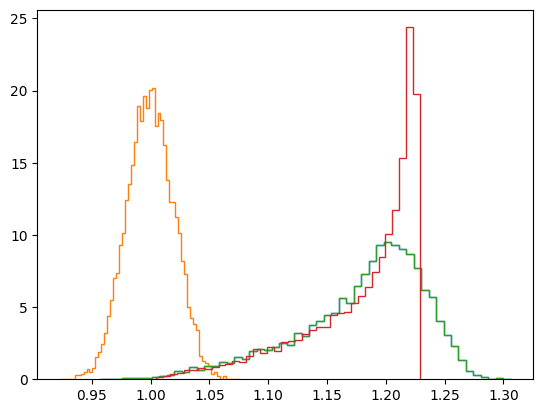

In [37]:
func=f(chi)
Munc=Mirr/mu

astropy.visualization.hist(Mirr, bins="freedman", histtype="step",density=True)
astropy.visualization.hist(M, bins="freedman", histtype="step",density=True)
astropy.visualization.hist(Munc, bins="freedman", histtype="step",density=True)
astropy.visualization.hist(func, bins="freedman", histtype="step",density=True)

In [38]:
def pi(f):
    return 2*(2*f**2-1)/(np.sqrt(1-f**2))

def p(Mirr,sigma):
    return np.sqrt(2/np.pi)/sigma*Monte(a,b,function, Mirr, f, mu, sigma)

def function(Mirr, f, mu, sigma):
    return np.exp(-(Mirr/(f-mu))**2/(2*sigma**2))*(2*f**2-1)/(f*np.sqrt(1-f**2))

def Monte(a,b,f,Mirr,mu,sigma):
    inte=np.sum(function(Mirr,f,mu,sigma)[f>a][f<b])/N
    return inte

In [39]:
print(scipy.stats.ks_2samp(Munc,func))

KstestResult(statistic=np.float64(0.1924), pvalue=np.float64(3.437795331154224e-162), statistic_location=np.float64(1.2247448699781907), statistic_sign=np.int8(-1))


0 0.1
KstestResult(statistic=np.float64(0.355), pvalue=np.float64(0.0), statistic_location=np.float64(1.2247448713505669), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.5848), pvalue=np.float64(0.0), statistic_location=np.float64(1.088548566877396), statistic_sign=np.int8(-1))
 
1 0.2
KstestResult(statistic=np.float64(0.4223), pvalue=np.float64(0.0), statistic_location=np.float64(1.2247448713505669), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.3253), pvalue=np.float64(1e-323), statistic_location=np.float64(1.1116137107049935), statistic_sign=np.int8(-1))
 
2 0.30000000000000004
KstestResult(statistic=np.float64(0.4499), pvalue=np.float64(0.0), statistic_location=np.float64(1.2247448713505669), statistic_sign=np.int8(-1))
KstestResult(statistic=np.float64(0.2247), pvalue=np.float64(1.4226246338039502e-221), statistic_location=np.float64(1.2252963259647556), statistic_sign=np.int8(-1))
 
3 0.4
KstestResult(statistic=np.float64(0.4643), pvalue=np.floa

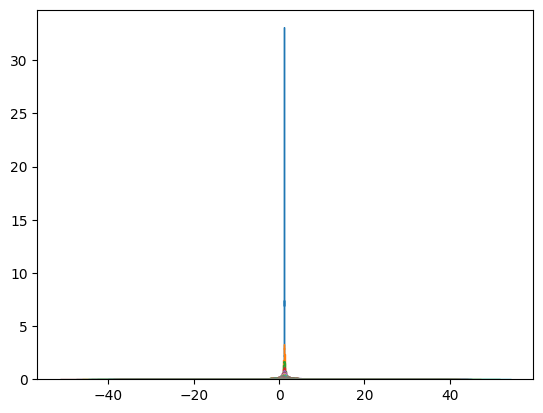

In [40]:
sigma=np.arange(0.1,10,0.1)
mu=1
N=10000
chi=np.random.uniform(0,1,N)
func=f(chi)
astropy.visualization.hist(func, bins="freedman", histtype="step",density=True)

for i in range(len(sigma)):
    M=scipy.stats.norm(loc=mu, scale=sigma[i]).rvs(N)
    Mirr=M_irr(M,chi)
    Munc=Mirr/mu
    astropy.visualization.hist(Munc, bins="freedman", histtype="step",density=True)
    print(i, sigma[i])
    print(scipy.stats.ks_2samp(Munc,func))
    print(scipy.stats.ks_2samp(Mirr,M))
    print(' ')

In [41]:
def littlef(chi):
    return ((1+(1-chi**2)**0.5)/2)**0.5

def plot_M_Mirr(scale):
    
    x = np.linspace(1-5*scale,1+5*scale,N)
    M = scipy.stats.norm.pdf(x, 1, scale)

    M=np.random.normal(loc=1,scale=scale,size=N)

    chi = np.random.uniform(0,1,N)
    m = littlef(chi)

    plt.hist(M*m,density=True,histtype='step',bins=80);

    x = np.linspace(min(1-5*scale,1/np.sqrt(2)),1+5*scale,N)

    def integrand(f,x):
        return ((2/np.pi)**0.5 / scale ) * np.exp(-(x/f -1)**2 /(2*scale**2)) * (2*f**2-1)/(1 - f**2)**0.5 / f

    Mirr = [scipy.integrate.quad(lambda f: integrand(f,xt), 1/2**0.5,1)[0] for xt in tqdm(x)]

    plt.plot(x,Mirr)
    plt.xlabel('$M_{\\rm irr}$');

  0%|          | 0/10000 [00:00<?, ?it/s]

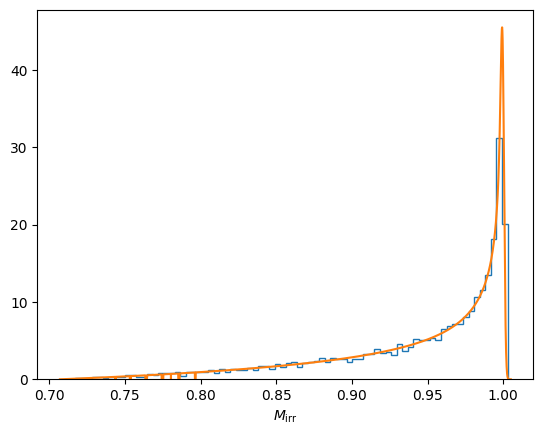

In [42]:
plot_M_Mirr(0.001)

  0%|          | 0/10000 [00:00<?, ?it/s]

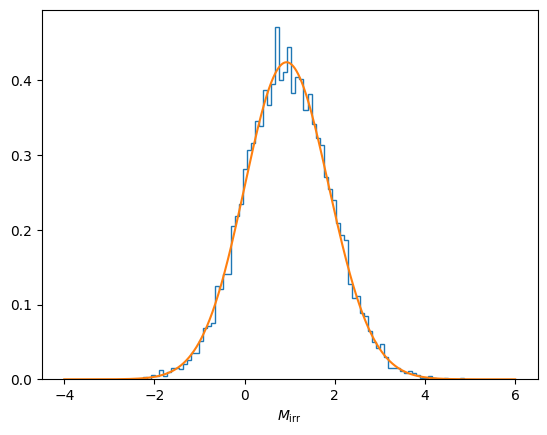

In [43]:
plot_M_Mirr(1)

In [45]:
m=littlef(chi)

scales= np.logspace(-5,5,20)
ksM=[]
ksf = []

N=100000
chi = np.random.uniform(0,1,N)
f = littlef(chi)
for scale in tqdm(scales):

    M=np.random.normal(loc=1,scale=scale,size=N)

    ksM.append(scipy.stats.ks_2samp(M, M*f))
    ksf.append(scipy.stats.ks_2samp(m, M*f))

ksM= np.array(ksM)
ksf= np.array(ksf)

  0%|          | 0/20 [00:00<?, ?it/s]

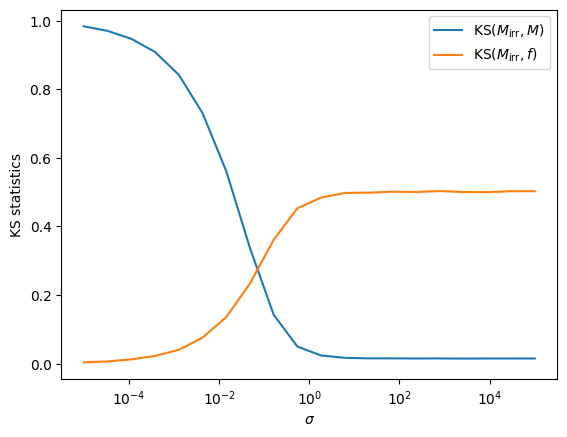

In [47]:
plt.plot(scales,ksM[:,0],label="KS$(M_{\\rm irr}, M)$")
plt.plot(scales,ksf[:,0],label="KS$(M_{\\rm irr}, f)$")
plt.semilogx()
plt.xlabel(r"$\sigma$")
plt.ylabel('KS statistics')
plt.legend();